In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

In [3]:
df = pd.read_csv('preprocessed_training_data.csv')

In [5]:
print(df['label'].value_counts())
print()
print(df['label'].isnull().sum())
print(df['clean_text'].isnull().sum())
print()
print(df.columns.to_list())
print()
print("text column datatype:")
print(df['text'].dtype)
print("label column datatype:")
print(df['label'].dtype)


label
1    172225
0    153997
Name: count, dtype: int64

0
0

['text', 'clean_text', 'label', 'num_chars', 'num_words', 'num_sentences']
['text', 'clean_text', 'label', 'num_chars', 'num_words', 'num_sentences']

text column datatype:
str
label column datatype:
int64


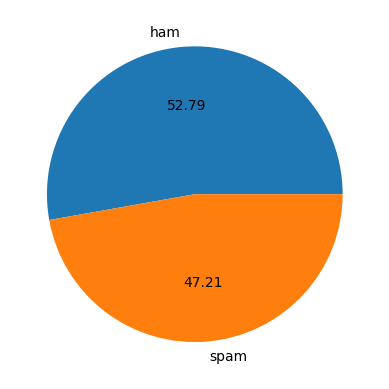

In [6]:
plt.figure()
plt.pie(df['label'].value_counts(), labels = ['ham', 'spam'], autopct = '%0.2f')
plt.show()

In [7]:
print("Statistics for ham emails:")
print()
print(df[df['label'] == 0][['num_chars', 'num_words', 'num_sentences']].describe())
print()
print("Statistics for spam emails:")
print()
print(df[df['label'] == 1][['num_chars', 'num_words', 'num_sentences']].describe())

Statistics for ham emails:

          num_chars     num_words  num_sentences
count  1.539970e+05  1.539970e+05  153997.000000
mean   1.688004e+03  2.676351e+02       3.805178
std    3.210384e+04  4.472783e+03      22.171871
min    2.000000e+00  1.000000e+00       1.000000
25%    1.410000e+02  2.800000e+01       1.000000
50%    5.670000e+02  9.300000e+01       1.000000
75%    1.483000e+03  2.440000e+02       3.000000
max    1.151031e+07  1.585483e+06    2827.000000

Statistics for spam emails:

          num_chars      num_words  num_sentences
count  1.722250e+05  172225.000000  172225.000000
mean   1.047375e+03     151.555378       2.818516
std    1.072640e+04     396.417329      13.809335
min    2.000000e+00       1.000000       1.000000
25%    1.820000e+02      29.000000       1.000000
50%    3.790000e+02      58.000000       1.000000
75%    1.034000e+03     159.000000       2.000000
max    4.279526e+06  107710.000000    3093.000000


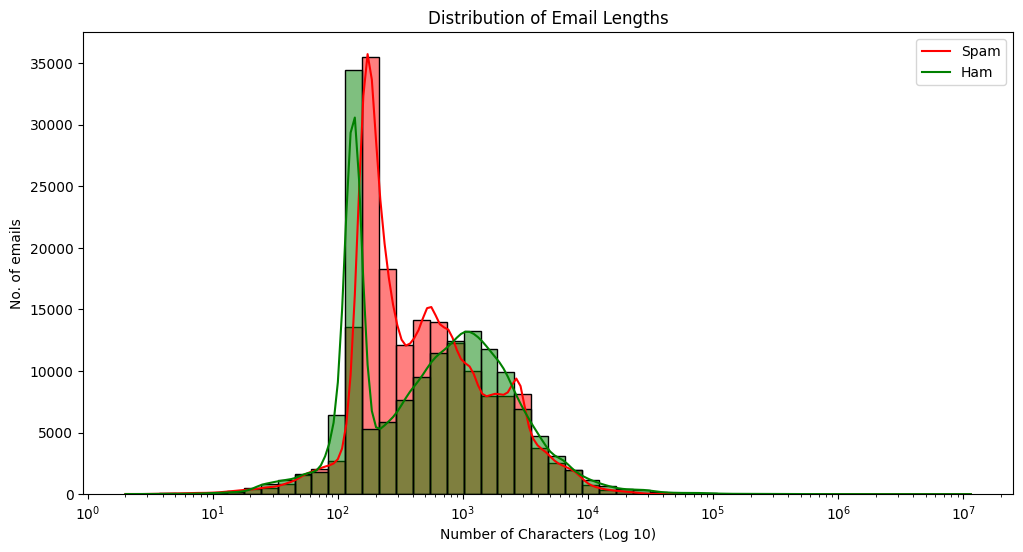

In [19]:
df_visual = df[df['num_chars'] < 10000]

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df, 
    x='num_chars', 
    hue='label', 
    log_scale=True, 
    bins=50, 
    kde=True,
    palette={0: 'green', 1: 'red'},
    alpha=0.5
)

plt.title('Distribution of Email Lengths')
plt.xlabel('Number of Characters (Log 10)')
plt.ylabel('No. of emails')
plt.legend(["Spam", "Ham"])
plt.show()

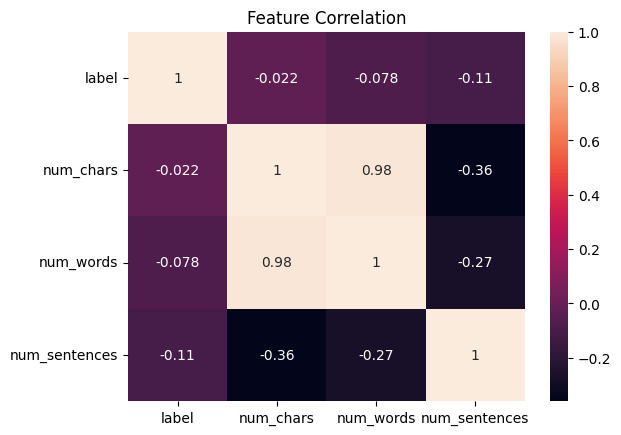

In [17]:
plt.figure()
sns.heatmap(df[['label', 'num_chars', 'num_words', 'num_sentences']].corr(method = 'spearman'), annot=True)
plt.title('Feature Correlation')
plt.show()

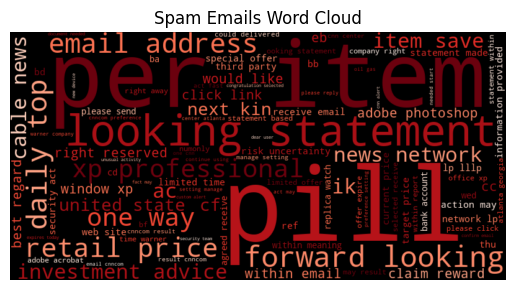

In [23]:
custom_stopwords = ['num', 'webaddr', 'emailaddr', 'currency', 'escapelong', 'numd', 'nummg', 'aug']
for i in range(97, 123):
    custom_stopwords.append(f'{chr(i)+'num'}')

spam_wc = WordCloud(
     width=800, 
     height=400, 
     background_color='black', 
     colormap='Reds',
     stopwords=custom_stopwords,
     max_words=100
).generate(df[df['label'] == 1]['clean_text'].str.cat(sep = ' '))
 
plt.figure()
plt.imshow(spam_wc, interpolation='bilinear')
plt.title('Spam Emails Word Cloud')
plt.axis('off')
plt.show()

In [24]:
null_count = df['clean_text'].isna().sum()
empty_string_count = (df['clean_text'].fillna('').str.strip() == '').sum()

print(f"Number of NaN / Null rows: {null_count}")
print(f"Number of completely blank strings: {empty_string_count}")

Number of NaN / Null rows: 0
Number of completely blank strings: 0


In [25]:
!jupyter nbconvert --to script exploratory_data_analysis.ipynb

[NbConvertApp] Converting notebook exploratory_data_analysis.ipynb to script
[NbConvertApp] Writing 2179 bytes to exploratory_data_analysis.py
